# Análisis Exploratorio - Dataset de geolocalización Olist

El Código postal de Brasil se compone de 8 dígitos con el objetivo que una guía acelerada para la distribución de objetos a través de correo. Se divide en 2 partes:  
**Parte 1: 5 dígitos**  
1) *Región:* Centro-oeste, Nordeste, Norte, Sudeste, Sur
2) *Sub-region:* Representan los estados de Brasil. Son 26 estados y 1 distrito federal. Cada uno con su abreviatura y cuenta con un rango específico de código
3) *Sector:* Representan las ciudades pertenecientes a cada estado
4) *Sub-sector*
5) *Sub-sector-divider*

**Parte 2: 3 dígitos**  
Representa el área de distribución

Para este dataset en particular nos interesa la parte de 5 dígitos, y en particular hasta los 3 primeros que identifican las ciudades de cada estado.



![Zipcode](https://youbianku.com/files/images/bra.jpg)

In [ ]:
!pip install datashader
!pip install geoviews

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import datashader as ds
import datashader.transfer_functions as tf
import colorcet as cc
import warnings
warnings.filterwarnings('ignore')
import geoviews as gv



# opciones de visualización de pandas
#pd.options.display.max_rows = 50
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
#Dataset
df = pd.read_csv('./olist_geolocation_dataset.csv',dtype={'geolocation_zip_code_prefix': str})

In [ ]:
#Agregamos una columna de Zipcode como numero para analizar distribución
df['zip_code_int']=df['geolocation_zip_code_prefix'].astype('int32')

In [ ]:
df.head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,zip_code_int
0,01037,-23.55,-46.64,sao paulo,SP,1037
1,01046,-23.55,-46.64,sao paulo,SP,1046
2,01046,-23.55,-46.64,sao paulo,SP,1046
3,01041,-23.54,-46.64,sao paulo,SP,1041
4,01035,-23.54,-46.64,sao paulo,SP,1035
5,01012,-23.55,-46.64,são paulo,SP,1012
6,01047,-23.55,-46.64,sao paulo,SP,1047
7,01013,-23.55,-46.63,sao paulo,SP,1013
8,01029,-23.54,-46.63,sao paulo,SP,1029
9,01011,-23.55,-46.64,sao paulo,SP,1011


## Tipo de dato y shape

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512742 entries, 0 to 512741
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  512742 non-null  object 
 1   geolocation_lat              512742 non-null  float64
 2   geolocation_lng              512741 non-null  float64
 3   geolocation_city             512741 non-null  object 
 4   geolocation_state            512741 non-null  object 
 5   zip_code_int                 512742 non-null  int32  
dtypes: float64(2), int32(1), object(3)
memory usage: 21.5+ MB


In [ ]:
df.shape

(512742, 6)

* El dataset cuenta con un poco mas de 1 millon de registros
* En cuanto a los tipos de datos, los campos de latitud y longitud son flotantes, ciudad y estado de tipo string. En el caso del zip code se decidió dejar una columna como string para mantener los ceros del inicio, y otro campo colocarlo como entero para hacer algun tipo de gráfico

## Valores nulos y duplicados

**Valores nulos**

In [ ]:
df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,1
geolocation_city,1
geolocation_state,1
zip_code_int,0


**Duplicados**  
Me interesa que los zip codes sean unicos, por lo que verifico solo duplicados en la columna _geolocation_zip_code_prefix_

In [ ]:
# Cuenta de Registros duplicados totales
registros_duplicados = df.duplicated().sum()
registros_duplicados

np.int64(157650)

In [ ]:
# Cuenta de duplicados por zipcode
zipcode_duplicados = df.duplicated(subset=['geolocation_zip_code_prefix']).sum()
zipcode_duplicados

np.int64(505145)

In [ ]:
# Porcentaje de duplicados
print(f'Porcentaje de registros duplicados: {round(registros_duplicados/df.shape[0]*100,2)} %')
print(f'Porcentaje de zipcodes duplicados: {round(zipcode_duplicados/df.shape[0]*100,2)} %')

Porcentaje de registros duplicados: 30.75 %
Porcentaje de zipcodes duplicados: 98.52 %


In [ ]:
# Elimino duplicados
df.drop_duplicates(subset=['geolocation_zip_code_prefix'], keep = 'first', inplace=True)

In [ ]:
# Verifico la forma del dataframe
df.shape

(7597, 6)

* No hay valores nulos en el dataset
* Hay registros duplicados en el dataset, siendo un 26 % de regitros iguales, mientras que los códigos postales duplicados llegarían al 98% del total de registros
* Al dejar los codigos postales únicos, solo quedan 19015 registros

## Análisis de variables

### Variables numéricas

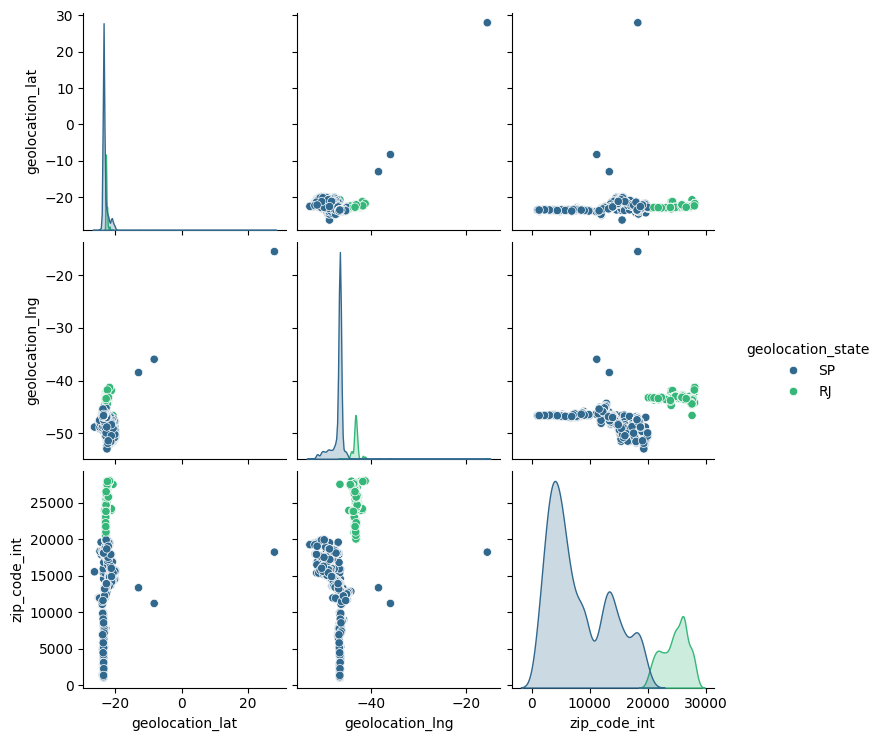

In [ ]:
#Pairplot para variables cuantitativas. con un hue en stay y sample del 10% datos
sns.pairplot(df.sample(frac=0.8), hue="geolocation_state", palette = 'viridis')
plt.show()

Observando la tercera columna se puede observar que:
* Para cada state le pertenece mas o menos un rango definido de zipcode
* En los gráficos de dispersión de latitud y longitud respecto al zipcode se pueden ver algunos puntos outliers, especialmente para latitud, lo que podría significar que esos puntos estén fuera de Brasil

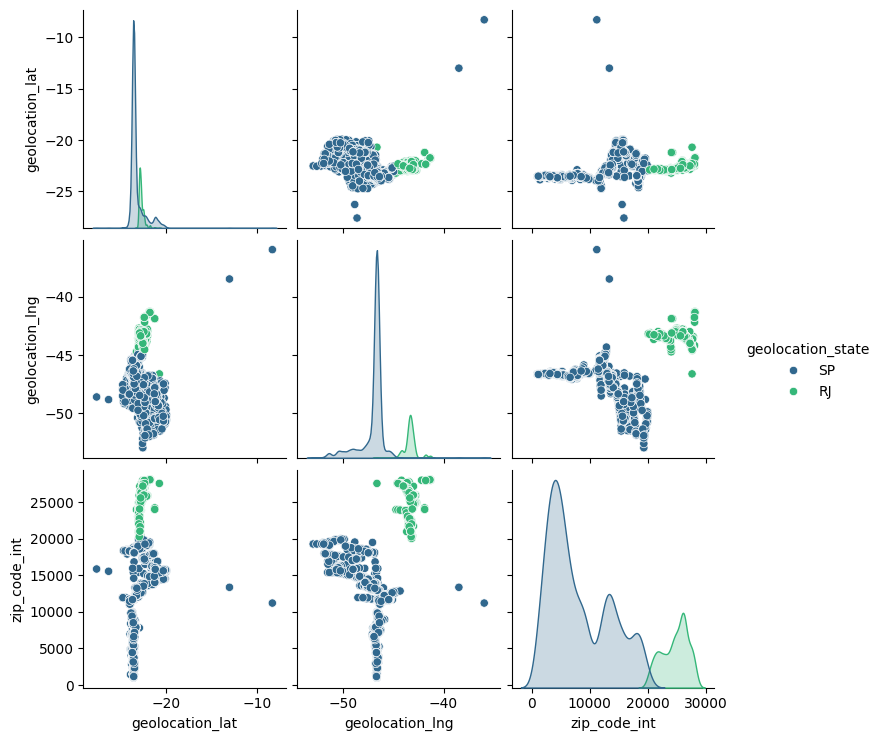

In [ ]:
#Pairplot para variables cuantitativas. con un hue en stay y sample del 10% datos
sns.pairplot(df.sample(frac=0.8), hue="geolocation_state", palette = 'viridis')
plt.show()

### Variables categóricas
* geolocation_city
* geolocation_state

#### geolocation_city

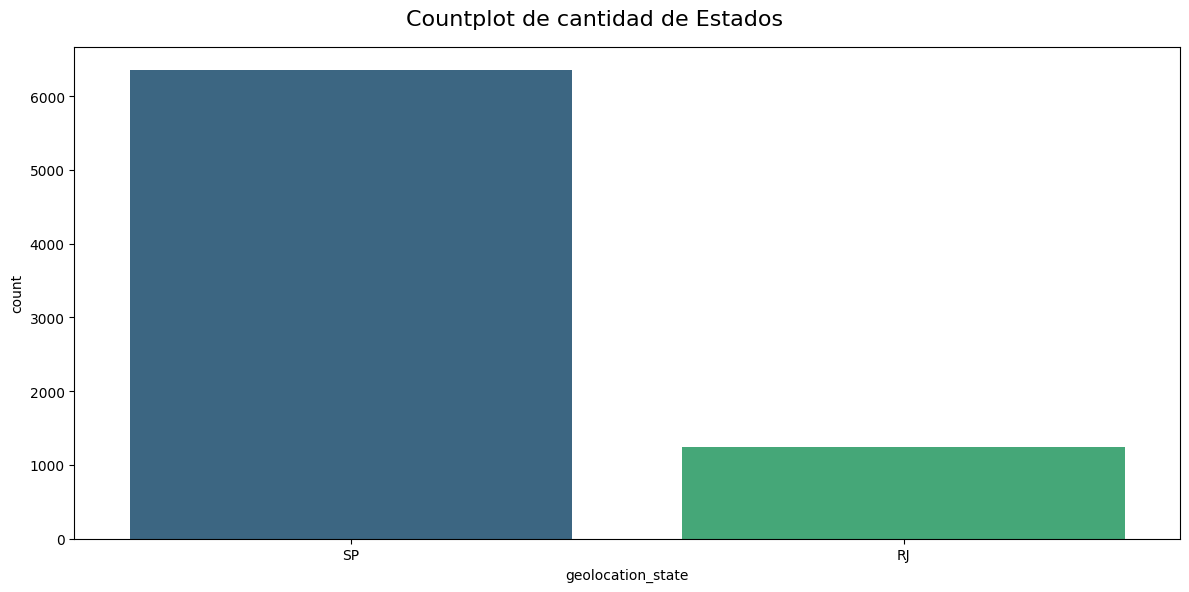

In [ ]:
# Ploteo de Estados
fig, ax = plt.subplots(figsize = (12,6))
sns.countplot(data = df, x = 'geolocation_state', ax = ax, palette = 'viridis')
fig.suptitle('Countplot de cantidad de Estados', fontsize=16,fontweight=200)
plt.tight_layout()
plt.show()

* Sao Paulo, Mina Gerais y Rio de Janeiro son los estados que cuentan con más cantidad de subdivisiones con alcance postal

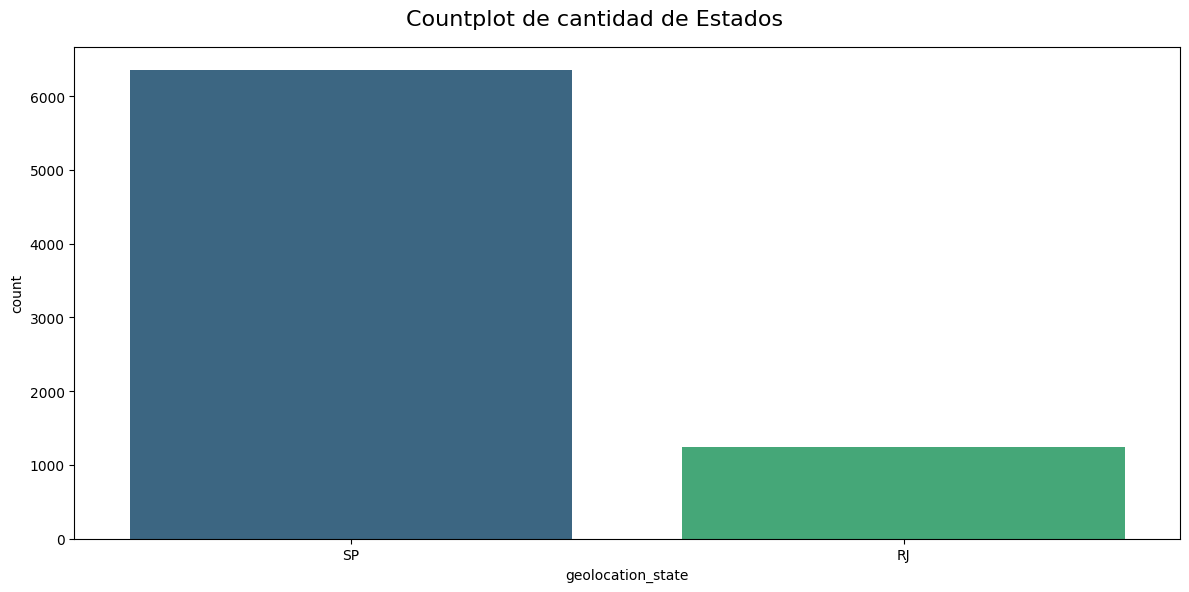

In [ ]:
# Ploteo de Estados
fig, ax = plt.subplots(figsize = (12,6))
sns.countplot(data = df, x = 'geolocation_state', ax = ax, palette = 'viridis')
fig.suptitle('Countplot de cantidad de Estados', fontsize=16,fontweight=200)
plt.tight_layout()
plt.show()

####  geolocation_state

In [ ]:
# Cantidad subdivisiones postales por ciudad
df['geolocation_city'].value_counts().sort_values(ascending=False).to_frame()

,count
geolocation_city,
sao paulo,2652
são paulo,528
rio de janeiro,400
guarulhos,139
sao bernardo do campo,123
...,...
aspasia,1
meridiano,1
indiapora,1


In [ ]:
# Cantidad subdivisiones postales por ciudad
df['geolocation_city'].value_counts().sort_values(ascending=False).to_frame()

,count
geolocation_city,
sao paulo,2652
são paulo,528
rio de janeiro,400
guarulhos,139
sao bernardo do campo,123
...,...
aspasia,1
meridiano,1
indiapora,1


* Al realizar un conteo de sub sectores por ciudad se pueden ver algunas inconsistencias con los nombres, por ejemplo las categorías sao paulo y são paulo deberían agruparse como una misma categoría. Hay que hacerse algunas transformaciones en los nombres para lograr una consistencia en los datos

### 1 - geolocation_zip_code_prefix

Describe de zipcode

In [ ]:
df['geolocation_zip_code_prefix'].value_counts().to_frame().describe()

,count
count,7597.00
mean,1.00
std,0.00
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,1.00


In [ ]:


# Diccionario con los estados de Brasil
estados_brasil = {
    'AC': 'Acre',
    'AM': 'Amazonas',
    'PA': 'Pará',
    'RO': 'Rondônia',
    'RR': 'Roraima',
    'AP': 'Amapá',
    'TO': 'Tocantins',
    'MA': 'Maranhão',
    'PI': 'Piauí',
    'CE': 'Ceará',
    'RN': 'Rio Grande do Norte',
    'PB': 'Paraíba',
    'PE': 'Pernambuco',
    'AL': 'Alagoas',
    'SE': 'Sergipe',
    'BA': 'Bahia',
    'MG': 'Minas Gerais',
    'ES': 'Espírito Santo',
    'RJ': 'Rio de Janeiro',
    'SP': 'São Paulo',
    'PR': 'Paraná',
    'SC': 'Santa Catarina',
    'RS': 'Rio Grande do Sul',
    'MS': 'Mato Grosso do Sul',
    'MT': 'Mato Grosso',
    'GO': 'Goiás',
    'DF': 'Distrito Federal'
}

# Convertir a DataFrame
df_estados = pd.DataFrame(list(estados_brasil.items()), columns=['Sigla', 'Estado'])

# Exportar a CSV
df_estados.to_csv('estados_brasil.csv', index=False)


In [ ]:
# Formateo ciudades

# Cargar el archivo CSV en un nuevo DataFrame llamado df_sellers
df_sellers = pd.read_csv('estados_brasil.csv', encoding='utf-8-sig')

# Mostrar el contenido para verificar
print(df_sellers.head())

# Sao Paulo
df_sellers.loc[df_sellers["Estado"] == "sao pauo", "seller_city"] = "sao paulo"
df_sellers.loc[df_sellers["Estado"] == "sao paluo", "seller_city"] = "sao paulo"
df_sellers.loc[df_sellers["Estado"] == "sp / sp", "seller_city"] = "sao paulo"
df_sellers.loc[df_sellers["Estado"] == "sao paulo sp", "seller_city"] = "sao paulo"
df_sellers.loc[df_sellers["Estado"] == "sao paulo / sao paulo", "seller_city"] = "sao paulo"
df_sellers.loc[df_sellers["Estado"] == "são paulo", "seller_city"] = "sao paulo"
df_sellers.loc[df_sellers["Estado"] == "sao paulop", "seller_city"] = "sao paulo"
df_sellers.loc[df_sellers["Estado"] == "sao paluo", "seller_city"] = "sao paulo"

# Rio de Janeiro
df_sellers.loc[df_sellers["Estado"] == "rio de janeiro / rj", "seller_city"] = "rio de janeiro"
df_sellers.loc[df_sellers["Estado"] == "rio de janeiro / rio de janeiro", "seller_city"] = "rio de janeiro"
df_sellers.loc[df_sellers["Estado"] == "rio de janeiro \rio de janeiro", "seller_city"] = "rio de janeiro"

# Sao Jose Do Rio Preto
df_sellers.loc[df_sellers["Estado"] == "sao jose do rio preto", "seller_city"] = "sao jose do rio preto"
df_sellers.loc[df_sellers["Estado"] == "sao jose do rio pret", "seller_city"] = "sao jose do rio preto"
df_sellers.loc[df_sellers["Estado"] == "s jose do rio preto", "seller_city"] = "sao jose do rio preto"

# Angra dos Reis
df_sellers.loc[df_sellers["Estado"] == "angra dos reis rj", "seller_city"] = "angra dos reis"

# Ribeirao Preto
df_sellers.loc[df_sellers["Estado"] == "ribeirao preto / sao paulo", "seller_city"] = "ribeirao preto"
df_sellers.loc[df_sellers["Estado"] == "robeirao preto", "seller_city"] = "ribeirao preto"

# Sao Jose Do Rio Preto
df_sellers.loc[df_sellers["Estado"] == "sao jose do rio pret", "seller_city"] = "sao jose do rio preto"
df_sellers.loc[df_sellers["Estado"] == "s jose do rio preto", "seller_city"] = "sao jose do rio preto"

# Sao Bernardo do Campo
df_sellers.loc[df_sellers["Estado"] == "sbc", "seller_city"] = "sao bernardo do campo"
df_sellers.loc[df_sellers["Estado"] == "sbc/sp", "seller_city"] = "sao bernardo do campo"

# Sao Jose Do Rio Pardo
df_sellers.loc[df_sellers["Estado"] == "scao jose do rio pardo", "seller_city"] = "sao jose do rio pardo"

# Sao Sebastiao Da Grama
df_sellers.loc[df_sellers["Estado"] == "sao sebastiao da grama/sp", "seller_city"] = "sao sebastiao da grama"

# Carapicuiba
df_sellers.loc[df_sellers["Estado"] == "carapicuiba / sao paulo", "seller_city"] = "carapicuiba"

# Jacarei
df_sellers.loc[df_sellers["Estado"] == "jacarei / sao paulo", "seller_city"] = "jacarei"

# Santa Barbara D'oeste
df_sellers.loc[df_sellers["Estado"] == "santa barbara d oeste", "seller_city"] = "santa barbara do oeste"

# Novo Hamburgo
df_sellers.loc[df_sellers["Estado"] == "novo hamburgo, rio grande do sul, brasil", "seller_city"] = "novo hamburgo"

# Cariacica
df_sellers.loc[df_sellers["Estado"] == "cariacica / es", "seller_city"] = "cariacica"

# Lages
df_sellers.loc[df_sellers["Estado"] == "lages - sc", "seller_city"] = "lages"

# Auriflama
df_sellers.loc[df_sellers["Estado"] == "auriflama/sp", "seller_city"] = "auriflama"

# Mogi das Cruzes
df_sellers.loc[df_sellers["Estado"] == "mogi das cruzes / sp", "seller_city"] = "mogi das cruzes"

# Andira
df_sellers.loc[df_sellers["Estado"] == "andira-pr", "seller_city"] = "andira"

# Barbacena
df_sellers.loc[df_sellers["Estado"] == "barbacena/ minas gerais", "seller_city"] = "barbacena"

# Arrial d´Ajuda
df_sellers.loc[df_sellers["Estado"] == "arraial d'ajuda (porto seguro)", "seller_city"] = "arrial d'ajuda"

# Brasilia
df_sellers.loc[df_sellers["Estado"] == "brasilia df", "seller_city"] = "brasilia"

# Maua
df_sellers.loc[df_sellers["Estado"] == "maua/sao paulo", "seller_city"] = "maua"

# Santo Andre
df_sellers.loc[df_sellers["Estado"] == "santo andre/sao paulo", "seller_city"] = "santo andre"

  Sigla    Estado
0    AC      Acre
1    AM  Amazonas
2    PA      Pará
3    RO  Rondônia
4    RR   Roraima


In [ ]:
print(df_sellers.columns)


Index(['Sigla', 'Estado'], dtype='object')


In [ ]:
print(df_sellers.head())

  Sigla    Estado
0    AC      Acre
1    AM  Amazonas
2    PA      Pará
3    RO  Rondônia
4    RR   Roraima


In [ ]:
import pandas as pd

# Cargar los datos de estados de Brasil
df_estados = pd.read_csv('estados_brasil.csv', encoding='utf-8-sig')

# Cargar el dataset de geolocalización
df_geo = pd.read_csv('olist_geolocation_dataset.csv', encoding='utf-8-sig')

# Unir los datasets usando la sigla del estado
df_geo_completo = df_geo.merge(df_estados, left_on='geolocation_state', right_on='Sigla', how='left')

# Verificar resultado
print(df_geo_completo[['geolocation_state', 'Estado']].head())

# (Opcional) Guardar el nuevo DataFrame en un archivo CSV
df_geo_completo.to_csv('olist_geolocation_dataset_completo.csv', index=False, encoding='utf-8-sig')


  geolocation_state     Estado
0                SP  São Paulo
1                SP  São Paulo
2                SP  São Paulo
3                SP  São Paulo
4                SP  São Paulo
